# Chapter 40 — The Spring Element: Designing the Elastic Foundation
### *Modern Strain Gage Technology* — Companion Notebook

**Every strain gage transducer is only as good as the piece of metal it is bonded to.** The *spring element* is that piece of metal — the mechanical component that deforms predictably under the input quantity (force, pressure, torque) and presents a well-defined strain field to the gages on its surface. It must be stiff enough not to disturb the system being measured (a force transducer should not deflect the structure it reads), yet compliant enough to produce measurable strain at the expected load.

The three classical spring element geometries serve different measurement needs. A *column* in axial compression is extremely stiff but produces low strain per unit force — suited to very large loads. A *cantilever beam* is far more compliant and produces high bending strain per unit force — suited to precision force measurement from newtons to kilonewtons. A *shear-web* beam exploits the shear stress distribution to minimize the influence of bending moments at the mounting points. Understanding the stiffness and strain sensitivity of each geometry is the first step in transducer design.

Companion notebook to Chapter 40 — The Spring Element: Designing the Elastic Foundation.

**This notebook demonstrates:**
1. Stiffness (N/mm) and strain sensitivity (με/N) for the three fundamental spring element geometries — column, cantilever beam, and shear-web — using the strain relations of §40.2 and §40.4.
2. The two schematic figures used in the chapter (Figures 40.1 and 40.2), generated here so they stay fully reproducible.

In [1]:
# !pip install numpy matplotlib
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon, Circle, Ellipse
from matplotlib.transforms import Affine2D

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

---
## 1 — Spring Element Stiffness and Strain Sensitivity

The most striking result below is the enormous sensitivity difference between the column and the cantilever beam. A steel column with a 100 mm² cross-section produces about 0.05 με/N of axial strain — a very low sensitivity that requires large forces (tens of kilonewtons) to produce measurable bridge output. The same material in a cantilever geometry produces 16.7 με/N of bending strain at the root — roughly 333× more sensitive per newton applied. The tradeoff is stiffness: this cantilever is about 3,700× less stiff than the column.

The shear-web falls between the two in sensitivity (0.13 με/N) and offers a different advantage — its output strongly *rejects* bending moments applied at the mounting points (good rejection, not perfect immunity — off-axis sensitivity still depends on machining tolerance and bridge balance, as §40.3 stresses), making it useful for force transducers where the load path is not perfectly controlled. One subtlety: the shear value below is the engineering shear strain *γ* at the web's neutral axis, and the ±45° gages actually read the normal strain *ε = γ/2* along the principal directions — so their per-newton strain reading is half the quoted γ. Either way, the shear-web sits between the column and the cantilever. These stiffness and sensitivity numbers are the starting inputs to any transducer design; with them in hand, material and geometry can be iterated to meet the target specifications.

In [2]:
# --- Material: structural steel -------------------------------------------
E_STEEL = 200e3                              # elastic modulus, MPa (= 200 GPa)
NU_STEEL = 0.30                              # Poisson's ratio, dimensionless
G_STEEL = E_STEEL / (2 * (1 + NU_STEEL))     # shear modulus, MPa
UE_PER_STRAIN = 1e6                          # microstrain per unit strain


def column_response(area, length, E=E_STEEL):
    """Column in axial load.

    Returns (k, sensitivity):
      k           axial stiffness EA/L, in N/mm
      sensitivity axial strain per unit force 1/(A*E), in me/N (microstrain/N)
    With E in MPa (N/mm^2) and area in mm^2, E*A/L has units N/mm.
    """
    k = E * area / length
    sensitivity = 1.0 / (area * E) * UE_PER_STRAIN
    return k, sensitivity


def cantilever_response(width, depth, length, E=E_STEEL):
    """Rectangular cantilever loaded transversely at the free end.

    Returns (k, sensitivity):
      k           tip stiffness 3EI/L^3, in N/mm  (I = b*h^3/12)
      sensitivity root surface strain per unit force 6L/(E*b*h^2), in me/N
    Implements the chapter's Eq. (40.1), eps_max = 6FL/(E*b*h^2), at F = 1 N.
    """
    I = width * depth**3 / 12.0
    k = 3 * E * I / length**3
    sensitivity = 6 * length / (width * depth**2 * E) * UE_PER_STRAIN
    return k, sensitivity


def shear_web_response(area, G=G_STEEL):
    """Shear-web element at the neutral axis (rectangular section).

    Returns the engineering shear-strain sensitivity gamma per unit force,
    3/(2*A*G), in me/N. Peak shear stress tau = 3V/(2A); gamma = tau/G.
    The +/-45 gages read normal strain eps = gamma/2 along the principal axes.
    """
    return 3.0 / (2 * area * G) * UE_PER_STRAIN


# --- Representative geometries (mm) ---------------------------------------
COLUMN_AREA, COLUMN_LENGTH = 100.0, 50.0        # mm^2, mm
BEAM_WIDTH, BEAM_DEPTH, BEAM_LENGTH = 10.0, 3.0, 50.0   # mm
SHEAR_WEB_AREA = 150.0                           # mm^2

k_col, sens_col = column_response(COLUMN_AREA, COLUMN_LENGTH)
k_beam, sens_beam = cantilever_response(BEAM_WIDTH, BEAM_DEPTH, BEAM_LENGTH)
gamma_shear = shear_web_response(SHEAR_WEB_AREA)

print("SPRING ELEMENT STIFFNESS AND STRAIN SENSITIVITY (steel, E = 200 GPa)")
print("=" * 68)
print(f"1. Column (axial load), A = {COLUMN_AREA:.0f} mm^2, L = {COLUMN_LENGTH:.0f} mm")
print(f"   k = {k_col:>10.0f} N/mm    sensitivity = {sens_col:7.4f} me/N (axial strain)")
print(f"2. Cantilever (bending), b = {BEAM_WIDTH:.0f}, h = {BEAM_DEPTH:.0f}, L = {BEAM_LENGTH:.0f} mm")
print(f"   k = {k_beam:>10.2f} N/mm    sensitivity = {sens_beam:7.4f} me/N (root surface strain)")
print(f"3. Shear-web, A = {SHEAR_WEB_AREA:.0f} mm^2, G = {G_STEEL:.0f} MPa")
print(f"   gamma sensitivity = {gamma_shear:7.4f} me/N   (+/-45 gages read eps = gamma/2 = {gamma_shear/2:.4f} me/N)")

SPRING ELEMENT STIFFNESS AND STRAIN SENSITIVITY (steel, E = 200 GPa)
1. Column (axial load), A = 100 mm^2, L = 50 mm
   k =     400000 N/mm    sensitivity =  0.0500 me/N (axial strain)
2. Cantilever (bending), b = 10, h = 3, L = 50 mm
   k =     108.00 N/mm    sensitivity = 16.6667 me/N (root surface strain)
3. Shear-web, A = 150 mm^2, G = 76923 MPa
   gamma sensitivity =  0.1300 me/N   (+/-45 gages read eps = gamma/2 = 0.0650 me/N)


---
## 2 — Spring Element Diagrams (Figures 40.1 and 40.2)

The two schematic figures used in the chapter are generated here so they stay reproducible. **Figure 40.1** shows the *bending* family as a progression — basic cantilever, width-tapered constant-stress beam, coupled dual-beam (binocular), and ring — matching the discussion in §40.2. **Figure 40.2** shows the two non-bending categories, the shear-web and the column, in the same front-over-plan layout, so that with Figure 40.1 all three fundamental categories behind the selection guidance in §40.5 are drawn. Both write PNGs into `src/media/ch40/`.

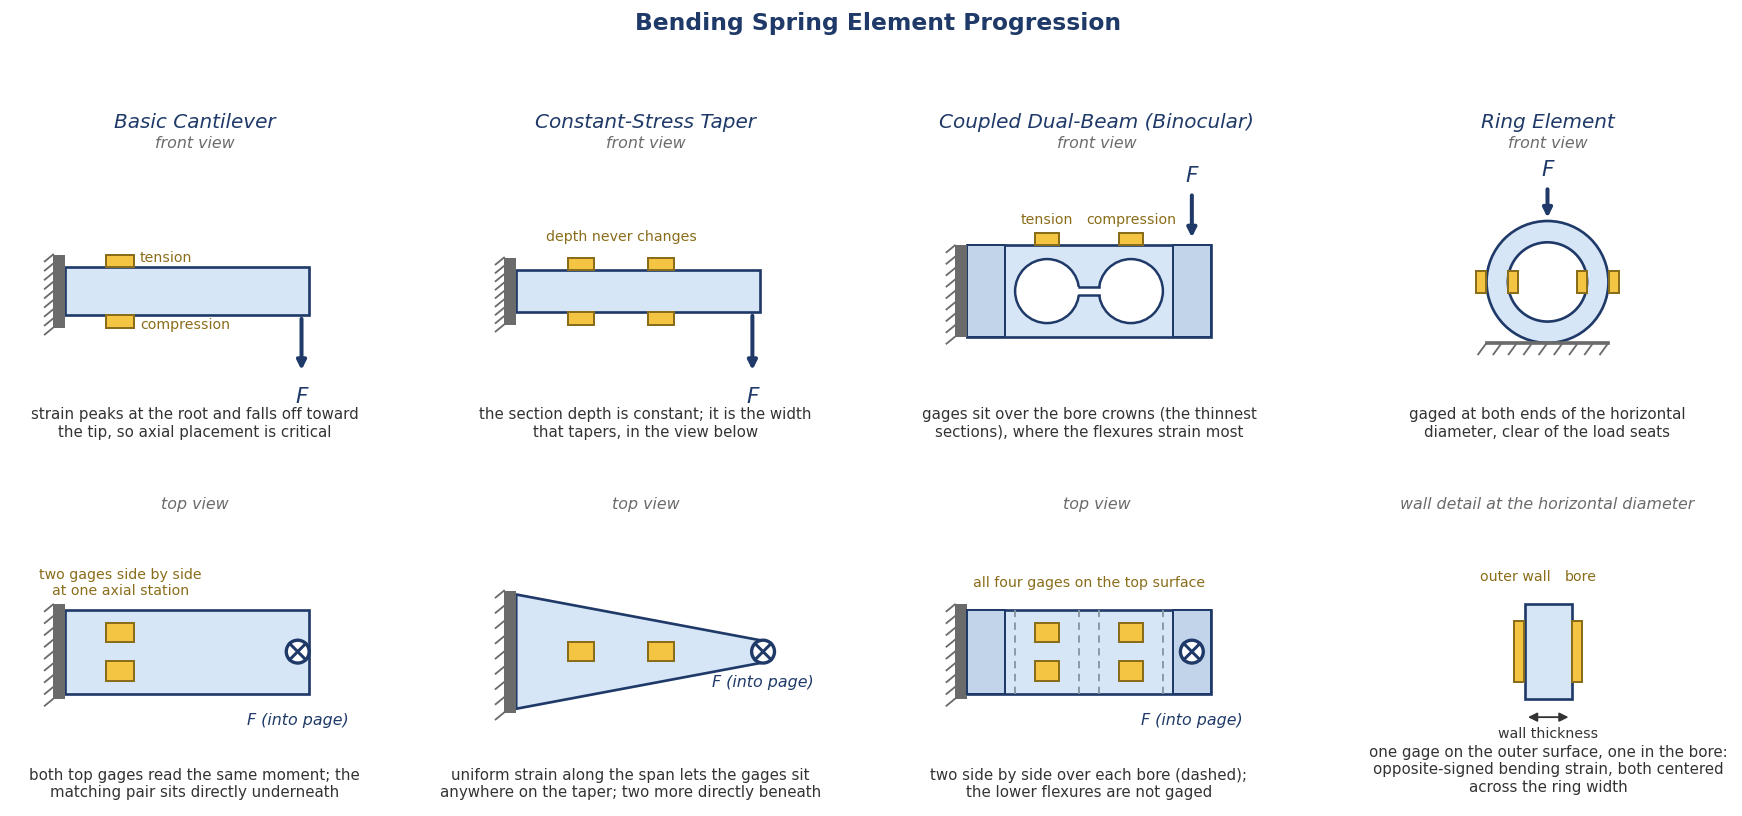

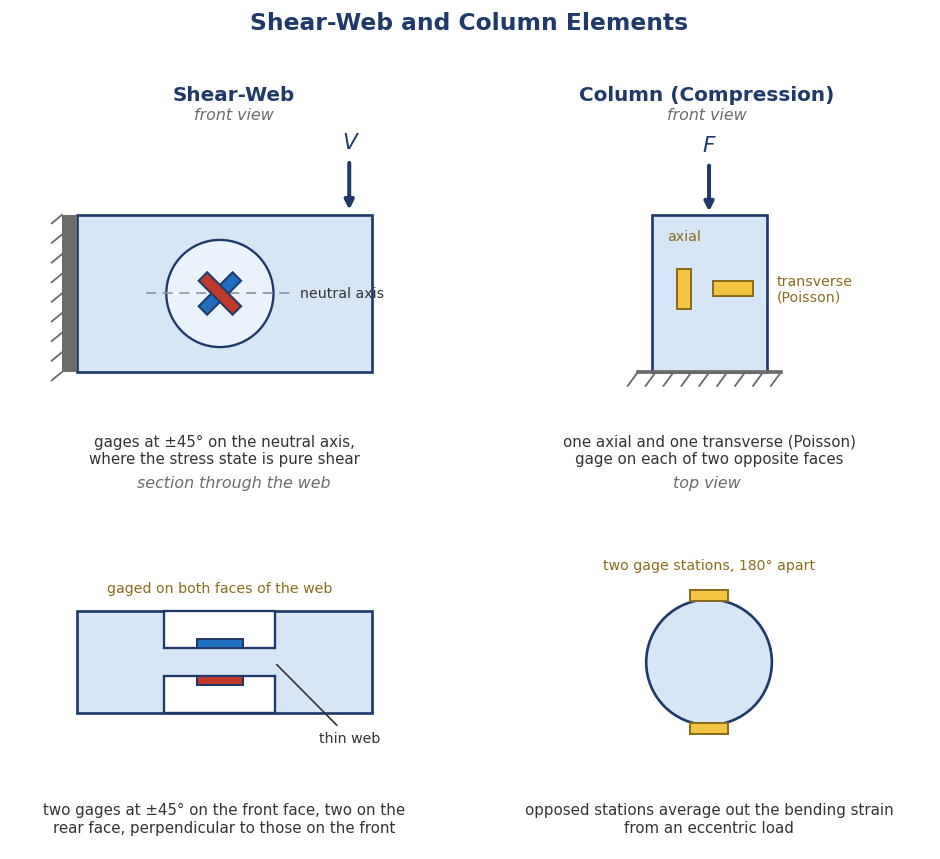

Figures written to ../src/media/ch40


In [3]:
# ---- palette (matches the book's other spring-element art) ----------------
BODY, EDGE = "#d7e6f7", "#1f3a68"
GAGE, GAGE_E = "#f4c542", "#8a6d1a"
GAGER, GAGEB = "#c0392b", "#1f6fc0"
LOAD, WALL, TXT = "#1f3a68", "#6b6b6b", "#333333"
BLOCK, HID, VIEW = "#c2d4ea", "#8794a3", "#6b6b6b"

# every panel shares one window so the top view sits at the same scale as the
# front view directly above it
XLIM, YLIM = (-0.7, 4.1), (-2.0, 1.8)

# resolve src/media/ch40 whether run from notebooks/ or the repo root
_root = os.getcwd()
if os.path.basename(_root) == "notebooks":
    _root = os.path.dirname(_root)
MEDIA = os.path.join(_root, "src", "media", "ch40")
os.makedirs(MEDIA, exist_ok=True)


def frame(ax, view):
    """Set up a panel and stamp which projection it shows."""
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_xlim(*XLIM); ax.set_ylim(*YLIM)
    ax.text(sum(XLIM)/2, 1.94, view, ha="center", va="center",
            fontsize=9.5, fontstyle="italic", color=VIEW)


def note(ax, x, s, y=-1.52):
    """Explanatory text under a panel."""
    ax.text(x, y, s, ha="center", va="top", fontsize=9, color=TXT)


def glabel(ax, x, y, s, ha="center", va="center"):
    """Small gage-colored annotation."""
    ax.text(x, y, s, ha=ha, va=va, fontsize=8.5, color=GAGE_E)


def wall(ax, x, y0, y1, w=0.16):
    """Draw a hatched fixed-support (ground) wall of width w at x, spanning y0..y1."""
    ax.add_patch(Rectangle((x - w, y0), w, y1 - y0, facecolor=WALL,
                           edgecolor="none", zorder=3))
    for yy in np.linspace(y0, y1, 9):
        ax.plot([x - w, x - w - 0.11], [yy, yy - 0.09], color=WALL, lw=1.1, zorder=3)


def ground(ax, x0, x1, y, n=9):
    """Draw a hatched reaction surface under a body, spanning x0..x1 at height y."""
    ax.plot([x0, x1], [y, y], color=WALL, lw=2.2, zorder=3)
    for xx in np.linspace(x0, x1, n):
        ax.plot([xx, xx - 0.11], [y, y - 0.15], color=WALL, lw=1.1, zorder=3)


def hidden(ax, x, y0, y1):
    """Dashed hidden-edge line for a feature below the visible surface."""
    ax.plot([x, x], [y0, y1], color=HID, lw=1.1, ls=(0, (4, 3)), zorder=5)


def gage(ax, cx, cy, w=0.30, h=0.16, color=GAGE, ec=GAGE_E, angle=0):
    """Draw a strain gage as a filled rectangle centered at (cx, cy), optionally rotated."""
    r = Rectangle((cx - w/2, cy - h/2), w, h, facecolor=color, edgecolor=ec, lw=1.2, zorder=6)
    if angle:
        r.set_transform(Affine2D().rotate_deg_around(cx, cy, angle) + ax.transData)
    ax.add_patch(r)


def load_arrow(ax, x, y, dy, label="F", lx=0.0, ly=None):
    """Draw a load arrow of vertical length dy from (x, y); ly overrides the label height."""
    ax.annotate("", xy=(x, y + dy), xytext=(x, y),
                arrowprops=dict(arrowstyle="-|>", color=LOAD, lw=2.4))
    if label:
        if ly is None:
            ly, va = y + dy + (0.12 if dy > 0 else -0.18), ("bottom" if dy > 0 else "top")
        else:
            va = "bottom"
        ax.text(x + lx, ly, label, ha="center", va=va,
                fontstyle="italic", fontsize=13, color=LOAD)


def into_page(ax, x, y, r=0.15, label="F (into page)", ly=None):
    """Draw the into-the-page load symbol (circled cross) at (x, y)."""
    ax.add_patch(Circle((x, y), r, facecolor="white", edgecolor=LOAD, lw=2.0, zorder=7))
    d = r * 0.707
    ax.plot([x - d, x + d], [y - d, y + d], color=LOAD, lw=1.8, zorder=8)
    ax.plot([x - d, x + d], [y + d, y - d], color=LOAD, lw=1.8, zorder=8)
    if label:
        ax.text(x, ly if ly is not None else y - r - 0.12, label, ha="center", va="top",
                fontstyle="italic", fontsize=9.5, color=LOAD)


def binocular_front(ax, y0, h, blk, r, c1, c2, slot, x0=0.0, w=3.2):
    """Binocular elevation: rigid end blocks, two bores joined by a slot, four flexures."""
    ax.add_patch(Rectangle((x0, y0), w, h, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
    for bx in (x0, x0 + w - blk):
        ax.add_patch(Rectangle((bx, y0), blk, h, facecolor=BLOCK, edgecolor=EDGE, lw=1.2, zorder=3))
    yc = y0 + h/2
    for cx in (c1, c2):
        ax.add_patch(Circle((cx, yc), r, facecolor="white", edgecolor=EDGE, lw=1.5, zorder=4))
    # the connecting slot merges the bores into one opening, leaving four thin flexures
    ax.add_patch(Rectangle((c1, yc - slot), c2 - c1, 2*slot, facecolor="white",
                           edgecolor="none", zorder=4.5))
    dx = np.sqrt(max(r**2 - slot**2, 0.0))
    for sy in (yc + slot, yc - slot):
        ax.plot([c1 + dx, c2 - dx], [sy, sy], color=EDGE, lw=1.5, zorder=5)


def plan_body(ax, y_half, x0=0.0, w=3.2, blk=None):
    """Plan outline of a prismatic body of half-width y_half, with optional end blocks."""
    ax.add_patch(Rectangle((x0, -y_half), w, 2*y_half, facecolor=BODY, edgecolor=EDGE,
                           lw=1.6, zorder=2))
    if blk:
        for bx in (x0, x0 + w - blk):
            ax.add_patch(Rectangle((bx, -y_half), blk, 2*y_half, facecolor=BLOCK,
                                   edgecolor=EDGE, lw=1.2, zorder=3))


# ==========================================================================
#  Figure 40.1 - bending-element progression, front view over top view
# ==========================================================================
fig, axes = plt.subplots(2, 4, figsize=(15, 7.2))

# ---- 1. basic cantilever -------------------------------------------------
ax = axes[0][0]; frame(ax, "front view")
ax.set_title("Basic Cantilever", fontsize=12, fontstyle="italic", color=EDGE, pad=16)
wall(ax, 0.0, -0.48, 0.48)
ax.add_patch(Rectangle((0.0, -0.32), 3.2, 0.64, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
gage(ax, 0.72, 0.40, w=0.36); gage(ax, 0.72, -0.40, w=0.36)
glabel(ax, 0.98, 0.44, "tension", ha="left"); glabel(ax, 0.98, -0.44, "compression", ha="left")
load_arrow(ax, 3.10, -0.32, -0.76, "F")
note(ax, 1.7, "strain peaks at the root and falls off toward\nthe tip, so axial placement is critical")

ax = axes[1][0]; frame(ax, "top view")
wall(ax, 0.0, -0.62, 0.62)
plan_body(ax, 0.55)
gage(ax, 0.72, 0.25, w=0.36, h=0.26); gage(ax, 0.72, -0.25, w=0.36, h=0.26)
glabel(ax, 0.72, 0.90, "two gages side by side\nat one axial station")
into_page(ax, 3.05, 0.0, ly=-0.80)
note(ax, 1.7, "both top gages read the same moment; the\nmatching pair sits directly underneath")

# ---- 2. constant-stress taper -------------------------------------------
ax = axes[0][1]; frame(ax, "front view")
ax.set_title("Constant-Stress Taper", fontsize=12, fontstyle="italic", color=EDGE, pad=16)
wall(ax, 0.0, -0.44, 0.44)
ax.add_patch(Rectangle((0.0, -0.28), 3.2, 0.56, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
for gx in (0.85, 1.90):
    gage(ax, gx, 0.36, w=0.34); gage(ax, gx, -0.36, w=0.34)
glabel(ax, 1.38, 0.72, "depth never changes")
load_arrow(ax, 3.10, -0.28, -0.80, "F")
note(ax, 1.7, "the section depth is constant; it is the width\nthat tapers, in the view below")

ax = axes[1][1]; frame(ax, "top view")
wall(ax, 0.0, -0.80, 0.80)
ax.add_patch(Polygon([(0.0, 0.75), (0.0, -0.75), (3.2, -0.15), (3.2, 0.15)], closed=True,
                     facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
for gx in (0.85, 1.90):
    gage(ax, gx, 0.0, w=0.34, h=0.24)
into_page(ax, 3.24, 0.0, ly=-0.30)
note(ax, 1.5, "uniform strain along the span lets the gages sit\nanywhere on the taper; two more directly beneath")

# ---- 3. coupled dual-beam (binocular) -----------------------------------
ax = axes[0][2]; frame(ax, "front view")
ax.set_title("Coupled Dual-Beam (Binocular)", fontsize=12, fontstyle="italic", color=EDGE, pad=16)
binocular_front(ax, y0=-0.60, h=1.20, blk=0.50, r=0.42, c1=1.05, c2=2.15, slot=0.05)
wall(ax, 0.0, -0.60, 0.60)
gage(ax, 1.05, 0.68, w=0.32); gage(ax, 2.15, 0.68, w=0.32)
glabel(ax, 1.05, 0.94, "tension"); glabel(ax, 2.15, 0.94, "compression")
load_arrow(ax, 2.95, 1.30, -0.64, "F", ly=1.38)
note(ax, 1.6, "gages sit over the bore crowns (the thinnest\nsections), where the flexures strain most")

ax = axes[1][2]; frame(ax, "top view")
wall(ax, 0.0, -0.62, 0.62)
plan_body(ax, 0.55, blk=0.50)
for cx in (1.05, 2.15):
    for dx in (-0.42, 0.42):
        hidden(ax, cx + dx, -0.55, 0.55)
    gage(ax, cx, 0.25, w=0.32, h=0.26); gage(ax, cx, -0.25, w=0.32, h=0.26)
into_page(ax, 2.95, 0.0, ly=-0.80)
glabel(ax, 1.60, 0.90, "all four gages on the top surface")
note(ax, 1.6, "two side by side over each bore (dashed);\nthe lower flexures are not gaged")

# ---- 4. ring element -----------------------------------------------------
cx, cy, ro, ri = 1.70, 0.12, 0.80, 0.52
ax = axes[0][3]; frame(ax, "front view")
ax.set_title("Ring Element", fontsize=12, fontstyle="italic", color=EDGE, pad=16)
ax.add_patch(Circle((cx, cy), ro, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
ax.add_patch(Circle((cx, cy), ri, facecolor="white", edgecolor=EDGE, lw=1.6, zorder=3))
for s in (-1, 1):
    gage(ax, cx + s*(ro + 0.07), cy, w=0.13, h=0.30)
    gage(ax, cx + s*(ri - 0.07), cy, w=0.13, h=0.30)
load_arrow(ax, cx, cy + ro + 0.46, -0.46, "F", ly=cy + ro + 0.54)
ground(ax, cx - 0.80, cx + 0.80, cy - ro)
note(ax, cx, "gaged at both ends of the horizontal\ndiameter, clear of the load seats")

ax = axes[1][3]; frame(ax, "wall detail at the horizontal diameter")
ax.add_patch(Rectangle((1.40, -0.62), 0.62, 1.24, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
gage(ax, 1.33, 0.0, w=0.13, h=0.80); gage(ax, 2.09, 0.0, w=0.13, h=0.80)
glabel(ax, 1.28, 0.98, "outer wall", ha="center"); glabel(ax, 2.14, 0.98, "bore", ha="center")
ax.annotate("", xy=(1.40, -0.86), xytext=(2.02, -0.86),
            arrowprops=dict(arrowstyle="<|-|>", color=TXT, lw=1.1))
ax.text(1.71, -0.98, "wall thickness", ha="center", va="top", fontsize=8.5, color=TXT)
note(ax, 1.71, "one gage on the outer surface, one in the bore:\nopposite-signed bending strain, both centered\nacross the ring width", y=-1.22)

fig.suptitle("Bending Spring Element Progression", fontsize=14, fontweight="bold",
             color=EDGE, y=0.995)
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig(os.path.join(MEDIA, "fig40_1_bending_progression.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()

# ==========================================================================
#  Figure 40.2 - the shear-web and column elements
# ==========================================================================
# Figure 40.1 already draws the bending family (cantilever, taper, binocular, ring),
# so this figure shows only the two non-bending types the later sections introduce.
fig, axes = plt.subplots(2, 2, figsize=(8.2, 7.2))

# ---- 1. shear-web --------------------------------------------------------
ax = axes[0][0]; frame(ax, "front view")
ax.set_title("Shear-Web", fontsize=12, fontweight="bold", color=EDGE, pad=16)
wall(ax, 0.0, -0.85, 0.85)
ax.add_patch(Rectangle((0.0, -0.85), 3.2, 1.70, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
ax.add_patch(Circle((1.55, 0.0), 0.58, facecolor="#eaf2fb", edgecolor=EDGE, lw=1.4, zorder=3))
ax.plot([0.75, 2.35], [0.0, 0.0], color=HID, lw=1.0, ls=(0, (6, 4)), zorder=4)
ax.text(2.42, 0.0, "neutral axis", ha="left", va="center", fontsize=8.5, color=TXT)
gage(ax, 1.55, 0.0, w=0.52, h=0.13, color=GAGEB, ec=EDGE, angle=45)
gage(ax, 1.55, 0.0, w=0.52, h=0.13, color=GAGER, ec=EDGE, angle=-45)
load_arrow(ax, 2.95, 1.45, -0.58, "V", ly=1.53)
note(ax, 1.6, "gages at ±45° on the neutral axis,\nwhere the stress state is pure shear")

ax = axes[1][0]; frame(ax, "section through the web")
plan_body(ax, 0.55)
ax.add_patch(Rectangle((0.95, 0.15), 1.20, 0.40, facecolor="white", edgecolor=EDGE, lw=1.4, zorder=4))
ax.add_patch(Rectangle((0.95, -0.55), 1.20, 0.40, facecolor="white", edgecolor=EDGE, lw=1.4, zorder=4))
gage(ax, 1.55, 0.20, w=0.50, h=0.10, color=GAGEB, ec=EDGE)
gage(ax, 1.55, -0.20, w=0.50, h=0.10, color=GAGER, ec=EDGE)
ax.annotate("thin web", xy=(2.14, 0.0), xytext=(2.62, -0.82), fontsize=8.5, color=TXT,
            ha="left", va="center", arrowprops=dict(arrowstyle="-", color=TXT, lw=1.0))
glabel(ax, 1.55, 0.80, "gaged on both faces of the web")
note(ax, 1.6, "two gages at ±45° on the front face, two on the\nrear face, perpendicular to those on the front")

# ---- 2. column -----------------------------------------------------------
ax = axes[0][1]; frame(ax, "front view")
ax.set_title("Column (Compression)", fontsize=12, fontweight="bold", color=EDGE, pad=16)
ax.add_patch(Rectangle((1.10, -0.85), 1.25, 1.70, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
gage(ax, 1.45, 0.05, w=0.16, h=0.44)
gage(ax, 1.98, 0.05, w=0.44, h=0.16)
glabel(ax, 1.45, 0.62, "axial")
glabel(ax, 2.45, 0.05, "transverse\n(Poisson)", ha="left")
load_arrow(ax, 1.72, 1.42, -0.57, "F", ly=1.50)
ground(ax, 0.95, 2.50, -0.85)
note(ax, 1.72, "one axial and one transverse (Poisson)\ngage on each of two opposite faces")

ax = axes[1][1]; frame(ax, "top view")
ax.add_patch(Circle((1.72, 0.0), 0.68, facecolor=BODY, edgecolor=EDGE, lw=1.6, zorder=2))
for sy in (-1, 1):
    gage(ax, 1.72, sy*0.72, w=0.42, h=0.12)
glabel(ax, 1.72, 1.05, "two gage stations, 180° apart")
note(ax, 1.72, "opposed stations average out the bending strain\nfrom an eccentric load")

fig.suptitle("Shear-Web and Column Elements", fontsize=14, fontweight="bold", color=EDGE, y=0.995)
fig.tight_layout(rect=(0, 0.0, 1, 0.97))
fig.savefig(os.path.join(MEDIA, "fig40_2_spring_comparison.png"), dpi=300,
            bbox_inches="tight", facecolor="white")
plt.show()
print("Figures written to", os.path.relpath(MEDIA).replace(os.sep, "/"))   # relative: no local path in saved output


---
## Where to take this next

The comparison above is deliberately minimal — a single operating point per geometry. A few concrete extensions turn it into a real design tool:

1. **Solve the inverse problem, as the chapter's worked example does.** Fix a target strain (say 1,500 με at rated load) and back out the beam length `L` from Eq. (40.1), then sweep `E`, `b`, and `h` to see which geometries can hit that target while keeping peak stress below the material's fatigue limit. Reproduce the chapter's 200 N, 2024‑T81 aluminum cantilever (answer: L ≈ 39.4 mm) as a check.
2. **Add the bridge and the estimated first natural frequency.** Convert each element's strain sensitivity into bridge output using the full‑bridge relations (GF·ε for a fully active bending bridge; the (1+ν)/2 factor of Eq. (40.3) for the column), and estimate `f_n ∝ √(k/m)` for a lumped end mass — making explicit the stiffness-vs-sensitivity tradeoff the chapter describes.
3. **Sweep the selection map.** Plot stiffness and sensitivity versus rated capacity for all three geometries on one figure and mark the ~4.4 kN (1,000 lb) bending-to-shear and ~50 kN shear-to-column crossover regions from §40.5, so the "choosing among the three" guidance becomes something you can see rather than memorize.